In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import sys
from matplotlib import rc
from matplotlib.ticker import FormatStrFormatter
from strawberryfields.decompositions import rectangular_symmetric

from OptiQuantum.convert_decomposition import strawberryfields_to_neuroptica_clements, strawberryfields_to_neuroptica_reck
from OptiQuantum.metrics import fidelity, visibility, transmittance, HOM_simple
from OptiQuantum.modified_strawberry.decompositions_new import triangular_symmetric
from OptiQuantum.modified_neuroptica.layers_new import ClementsLayer, ReckLayer, flipped_ReckLayer, DiamondLayer

Starting with an ideal transfer matrix, use Strawberry fields to decompose the matrix into Mach-Zehnder Interferometer(MZI) phase shifts.

These phase shifts must then be reordered into the form expected by neuroptica.

Here, the initial matrix is a random Haar-unitary matrix generated by Scipy.

In [2]:
N = 8 #Mesh size

matrix = scipy.stats.ortho_group.rvs(N) #Transfer matrix generation

In [3]:
print("The Haar-random matrix is:")
print(np.round(matrix,2))

The Haar-random matrix is:
[[-0.12 -0.08 -0.08  0.08 -0.16 -0.39 -0.77 -0.44]
 [ 0.52 -0.35 -0.1  -0.42  0.57 -0.06  0.01 -0.3 ]
 [ 0.12 -0.17 -0.05  0.67  0.36 -0.52  0.09  0.3 ]
 [ 0.66  0.18  0.02  0.47 -0.3   0.29  0.05 -0.37]
 [-0.39  0.19  0.29  0.3   0.58  0.37 -0.03 -0.41]
 [ 0.28 -0.02  0.58 -0.03  0.1   0.22 -0.53  0.5 ]
 [ 0.    0.08 -0.75  0.12  0.19  0.43 -0.34  0.28]
 [-0.18 -0.88  0.05  0.21 -0.21  0.33  0.04 -0.04]]


In [4]:
#Select whether to decompose the matrix onto a Clements or Reck mesh
mesh_type = 1 #Clements
#mesh_type = 2 #Reck

if mesh_type == 1:
    (tlist, localv, discard) = rectangular_symmetric(matrix) #Extract MZI phase shifts
    tlist = np.array(strawberryfields_to_neuroptica_clements(tlist, N)) #Convert to form compatible with neuroptica

elif mesh_type == 2:
    (tlist, localv, discard) = triangular_symmetric(matrix) #Extract MZI phase shifts
    tlist = np.array(strawberryfields_to_neuroptica_reck(tlist, N)) #Convert to form compatible with neuroptica

#Convert final phase shifts to a form compatible with neuroptica
localv = np.log(localv)/1j

Next, the phase shifts should be fed into neuroptica along with the desired values of loss and phase error.

Here, the same loss and phase error are applied to all MZIs.

However, it is also possible to apply a different loss and phase error to each MZI.

Note that the Reck layer used is a "flipped" Reck layer.

This means that the triangle points up instead of down.

In [5]:
phase_uncert = np.pi/32 #Standard deviation of phase in radians
phase_offset = 0 #Mean phase error in radians
loss_dB = 0.1 #Mean loss in dB
loss_diff = 0 #Standard deviation of loss in dB

#Extract only the phase shift data from the Strawberry Fields output
sz = np.shape(tlist)
phase_data = [(tlist[i,2] + phase_offset, tlist[i,3] + phase_offset) for i in range(sz[0])]

#Create mesh with neuroptica
if mesh_type == 1: #Clements mesh
    network = ClementsLayer(N, phases=phase_data, include_phase_shifter_layer=True, shifter_phases=localv, phase_uncert=phase_uncert, loss_dB=loss_dB, loss_diff=loss_diff)

if mesh_type == 2: #Reck Mesh
    network = flipped_ReckLayer(N, phases=phase_data, include_phase_shifter_layer=True, shifter_phases=localv, phase_uncert=phase_uncert, loss_dB=loss_dB, loss_diff=loss_diff)

mesh = network.mesh

In [6]:
print("The mesh transfer function is:")
print(str(np.real(np.round(mesh.get_transfer_matrix(),2))))
print("+")
print("j"+str(np.imag(np.round(mesh.get_transfer_matrix(),2))))


The mesh transfer function is:
[[-0.1  -0.07 -0.07  0.07 -0.14 -0.33 -0.66 -0.38]
 [ 0.45 -0.3  -0.09 -0.35  0.48 -0.06  0.01 -0.25]
 [ 0.11 -0.14 -0.04  0.57  0.31 -0.44  0.08  0.25]
 [ 0.56  0.15  0.01  0.4  -0.25  0.24  0.05 -0.31]
 [-0.34  0.16  0.24  0.26  0.48  0.31 -0.03 -0.34]
 [ 0.24 -0.02  0.48 -0.03  0.09  0.19 -0.45  0.43]
 [ 0.    0.06 -0.64  0.1   0.17  0.38 -0.3   0.26]
 [-0.15 -0.75  0.04  0.17 -0.18  0.29  0.03 -0.04]]
+
j[[ 0. -0. -0. -0. -0. -0. -0. -0.]
 [-0.  0.  0.  0.  0.  0. -0. -0.]
 [ 0. -0. -0. -0. -0.  0.  0. -0.]
 [ 0.  0. -0. -0.  0. -0. -0. -0.]
 [ 0. -0. -0. -0.  0.  0. -0. -0.]
 [-0. -0. -0. -0.  0.  0. -0. -0.]
 [ 0. -0.  0.  0.  0.  0. -0. -0.]
 [ 0.  0. -0. -0.  0. -0. -0.  0.]]


Note that for random errors to apply, the mesh must be randomized.

In [8]:
mesh.randomize_errors()
print("The mesh transfer function is now:")
print(str(np.real(np.round(mesh.get_transfer_matrix(),2))))
print("+")
print("j"+str(np.imag(np.round(mesh.get_transfer_matrix(),2))))

The mesh transfer function is now:
[[-0.06 -0.09 -0.12  0.08 -0.09 -0.33 -0.63 -0.41]
 [ 0.49 -0.24 -0.07 -0.33  0.48 -0.08  0.08 -0.23]
 [ 0.13 -0.05  0.02  0.56  0.28 -0.43  0.06  0.3 ]
 [ 0.54  0.11  0.04  0.38 -0.32  0.25  0.05 -0.27]
 [-0.31  0.18  0.26  0.28  0.44  0.23  0.05 -0.37]
 [ 0.2   0.05  0.41 -0.07  0.09  0.18 -0.42  0.37]
 [-0.01  0.06 -0.66  0.14  0.2   0.35 -0.19  0.19]
 [-0.14 -0.77  0.08  0.18 -0.08  0.24  0.01  0.01]]
+
j[[ 0.01 -0.    0.    0.01 -0.01  0.02  0.09 -0.01]
 [ 0.11 -0.06  0.02  0.    0.04 -0.1   0.01  0.04]
 [ 0.11 -0.03 -0.02  0.08  0.1   0.04 -0.01 -0.02]
 [-0.01 -0.01 -0.05  0.01  0.04 -0.08 -0.04  0.07]
 [-0.01 -0.01 -0.   -0.02 -0.12 -0.15  0.03  0.08]
 [-0.05 -0.02 -0.09 -0.   -0.09 -0.19  0.3  -0.16]
 [ 0.   -0.   -0.07  0.05 -0.11 -0.11  0.12 -0.01]
 [ 0.01  0.03 -0.02 -0.01  0.   -0.07  0.01  0.  ]]


Finally, the mesh is used to evaluate fidelity and biphoton transmittance.

Hong-Ou-Mandel(HOM) interferometry and HOM visibility require a special testing mesh.

In [10]:
#Evaluate the fidelity of the mesh against the original Haar matrix
fidel = fidelity(mesh,matrix)
print("The fidelity of the original mesh against the original Haar matrix is: " + str(fidel))

#Evaluate the fidelity of the mesh against a variation with no losses or errors
fidel_self = fidelity(mesh)
print("The fidelity of the original mesh against the ideal mesh is: " + str(fidel_self))

#Evaluate the biphoton transmittance of input paths 1 and 2 and output paths 1 and 2
input1 = 0
input2 = 1
output1 = 0
output2 = 1

transmit = transmittance(mesh,input1,input2,output1,output2)
print("The biphoton transmittance from inputs " + str(input1 + 1) + " and " + str(input2 + 1) + " to outputs "
      + str(output1 + 1) + " and " + str(output2 + 1) + "is: " + str(np.round(transmit,2)))

#Evaluate the transmittance of input paths 1 and 2 and output paths 1 and 2 without losses
transmit_norm = transmittance(mesh,input1,input2,output1,output2, add_uncertainties=False, add_loss=False)

print("The normalized biphoton transmittance from inputs " + str(input1 + 1) + " and " + str(input2 + 1) + " to outputs "
      + str(output1 + 1) + " and " + str(output2 + 1) + " is: " + str(np.round(transmit/transmit_norm,2)))

The fidelity of the original mesh against the original Haar matrix is: 0.9282229127338963
The fidelity of the original mesh against the ideal mesh is: 0.9282229127338955
The biphoton transmittance from inputs 1 and 2 to outputs 1 and 2is: -0j
The normalized biphoton transmittance from inputs 1 and 2 to outputs 1 and 2 is: (0.39-0j)


To evaluate HOM interferometry and visibility, a mesh with one MZI set to act as a 50:50 beam splitter and all other MZIs set to bar state should be used.

The MZI acting as a beam splitter will be the MZI under test.

In [11]:
#Create mesh with all MZIs acting as beam splitters
mesh_type = 1 #Clements
#mesh_type = 2 #Reck
#mesh_type = 3 #Bokun

if mesh_type == 1:
    num_mzis = int(N*(N-1)/2)
    HOM_network = ClementsLayer(N, phases=[(np.pi, np.pi) for _ in range(num_mzis)])
elif mesh_type == 2:
    num_mzis = int(N*(N-1)/2)
    HOM_network = ReckLayer(N, phases=[(np.pi, np.pi) for _ in range(num_mzis)])
elif mesh_type == 3:
    num_mzis = (N-1)**2
    HOM_network = DiamondLayer(N, phases=[(np.pi, np.pi) for _ in range(num_mzis)])
HOM_mesh = HOM_network.mesh

#Set the first MZI to act as a beam splitter (Leftmost for Reck and Bokun, upper-leftmost for Clements)
mzi_ut = HOM_mesh.layers[0].mzis[0] #MZI Under Test
mzi_ut.theta = np.pi/2
mzi_ut.phi = 0

HOM interferometry requires two more parameters: time delay tau and photon frequency standard deviation.

The following values used to calculate standard deviation are taken from [1].

In [12]:
lengths = np.linspace(-0.3, 0.3, 501) #Delay lengths (mm) for iteration
taus = lengths/(3*10**11) #Conversion to delay time (l(m)/c(m/s))
wavelength = 1550*(10**-9) #Wavelength from [1]]
dlambda = 12*(10**-9)/(2*np.sqrt(2*np.log(2))) #FWHM from [1]] converted to standard deviation
sigma = (2*np.pi)*(3*(10**8))/(wavelength**2)*dlambda #Conversion to frequency uncertainty

Plotting over a range of taus should give a HOM plot, as shown:

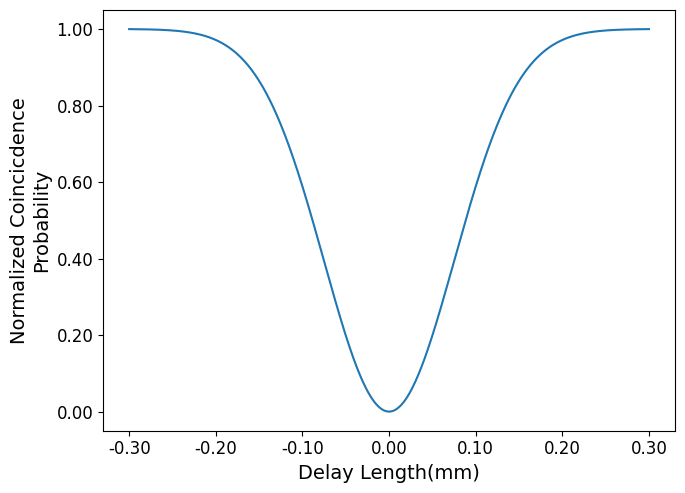

In [18]:
coincs = 2*HOM_simple(HOM_mesh, mzi_ut.m, mzi_ut.n, mzi_ut.m, mzi_ut.n, taus, sigma)

#Plotting code from ONN_Simulation_Class.py
labels_size = 14
rc('text.latex', preamble=r'\usepackage{mathptmx}')

plt.figure(figsize=(6.95, 5.03)) # compress the graph (around) quarter in size, by cutting top half and compress horizontally
plt.plot(lengths,coincs,label='Simulated HOM curve')

ax = plt.gca()
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='both', which='minor', labelsize=12)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.xlabel('Delay Length(mm)', fontsize=labels_size)
plt.ylabel('Normalized Coincicdence\nProbability', fontsize=labels_size)
plt.tight_layout()


The visibility is the difference between the minimum and maximum of this curve.

In [22]:
visib = visibility(HOM_mesh, mzi_ut.m, mzi_ut.n, mzi_ut.m, mzi_ut.n)
print("Visibility = " + str(np.round(visib,2)))

Visibility = (1-0j)
